### Imports & Data Load

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("data/cleaned_diabetic_data.csv")
df.shape


(63595, 40)

In [4]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[40-50),1,4,7,14,69,0,16,...,No,No,No,Down,No,No,No,Ch,Yes,0
1,Other,Female,[40-50),1,1,7,14,73,6,26,...,No,No,No,Up,No,No,No,Ch,Yes,0
2,Hispanic,Female,[50-60),1,6,7,14,69,0,25,...,No,No,No,Steady,No,No,No,No,Yes,0
3,AfricanAmerican,Male,[40-50),1,6,7,14,65,2,34,...,No,No,No,Up,No,No,No,Ch,Yes,0
4,Caucasian,Male,[50-60),3,1,1,14,63,4,30,...,No,No,No,Down,No,No,No,Ch,Yes,0


In [5]:
df.isnull().sum()

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide                  0
insulin   

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["readmitted"].value_counts()

readmitted
0    59058
1     4537
Name: count, dtype: int64

### Feature Engineering

Three transformations are applied here:

1. **Diagnosis code simplification** — `diag_1`, `diag_2`, `diag_3` contain 700+ raw ICD-9 codes, far too many distinct categories for a model to learn from reliably. They are mapped into 9 broad clinical categories (Circulatory, Diabetes, Respiratory, etc.), based on standard ICD-9 chapter ranges.
2. **Age ordinal encoding** — `age` is stored as text brackets (`[40-50)`), which has a genuine natural order. It is encoded as ordinal integers (0–9) rather than one-hot, since the order is meaningful.
3. **New composite feature** — `total_prior_visits`, the sum of a patient's prior outpatient, emergency, and inpatient visits, as a single utilization-history feature.

In [8]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[40-50),1,4,7,14,69,0,16,...,No,No,No,Down,No,No,No,Ch,Yes,0
1,Other,Female,[40-50),1,1,7,14,73,6,26,...,No,No,No,Up,No,No,No,Ch,Yes,0
2,Hispanic,Female,[50-60),1,6,7,14,69,0,25,...,No,No,No,Steady,No,No,No,No,Yes,0
3,AfricanAmerican,Male,[40-50),1,6,7,14,65,2,34,...,No,No,No,Up,No,No,No,Ch,Yes,0
4,Caucasian,Male,[50-60),3,1,1,14,63,4,30,...,No,No,No,Down,No,No,No,Ch,Yes,0


In [9]:
df["diag_2"].unique()

array(['305', '599', '276', '250.82', '682', '507', '785', '300', 'V54',
       '707', 'V62', '780', '518', 'V45', '799', '440', '486', '428',
       '788', '436', '492', '789', '997', '427', '250.22', '263', '574',
       '250.6', '425', '517', '403', '153', '491', '198', '496', '998',
       '8', '416', '250', '285', '424', '493', '585', '584', '569', '426',
       '250.41', '250.7', '511', '414', '821', '995', '411', '415', '790',
       '721', '250.02', '38', '730', '41', '401', '197', 'V49', '648',
       '421', '438', '553', '850', '250.93', '453', '396', '852', '40',
       '576', '340', '596', '571', '196', '250.52', '410', '331', '431',
       '433', '531', '189', '711', '203', '560', '434', '253', '294',
       '157', '200', '250.01', '482', '781', '820', '578', '272', '185',
       '577', '728', '277', '286', '332', '797', '557', '787', '342',
       '296', '404', '304', '284', '311', '485', '515', '162', '535',
       '250.81', '250.03', '250.4', '348', '437', '996', '312',

### Map diagnosis codes into 9 clinical categories

In [10]:
def map_diagnosis_codes(code):
    code = str(code)
    if code.startswith("V") or code.startswith("E"):
        return "other"

    try:
        code_num = float(code)
    except ValueError:
        return "other"
    if 250 <= code_num < 251:
        return "Diabetes"
    elif (390 <=  code_num <= 459) or code_num == 785:
        return "Circulatory"
    elif (460 <= code_num <= 519) or code_num == 786:
        return "Respiratory"
    elif (520 <= code_num <= 579) or code_num == 787:
        return "Digestive"
    elif (580 <= code_num <= 629) or code_num == 788:
        return "Genitourinary"
    elif 800 <= code_num <= 999:
        return "Injury"
    elif 710 <= code_num <= 739:
        return "Musculoskeletal"
    elif 140 <= code_num <= 239:
        return "Neoplasms"
    else:
        return "other"
for col in ["diag_1","diag_2","diag_3"]:
    df[col] = df[col].apply(map_diagnosis_codes)

print(df["diag_1"].value_counts())

diag_1
Circulatory        19118
other              11426
Respiratory         8592
Digestive           6093
Diabetes            4793
Injury              4402
Musculoskeletal     3551
Genitourinary       3269
Neoplasms           2351
Name: count, dtype: int64


**Insight:** Circulatory conditions are the most common primary diagnosis (~30%), consistent with the well-known link between diabetes and cardiovascular complications.

In [11]:
df["diag_1"].unique()

array(['other', 'Genitourinary', 'Circulatory', 'Diabetes', 'Respiratory',
       'Injury', 'Digestive', 'Neoplasms', 'Musculoskeletal'],
      dtype=object)

In [12]:
df["diag_2"].unique()

array(['other', 'Genitourinary', 'Diabetes', 'Respiratory', 'Circulatory',
       'Injury', 'Digestive', 'Neoplasms', 'Musculoskeletal'],
      dtype=object)

In [13]:
df["diag_3"].unique()

array(['Diabetes', 'Respiratory', 'Circulatory', 'Injury', 'Digestive',
       'other', 'Neoplasms', 'Genitourinary', 'Musculoskeletal'],
      dtype=object)

### Ordinal Encoding

In [14]:
from sklearn.preprocessing import OrdinalEncoder
age_order = [f"[{i}-{i+10})" for i in range(0,100,10)]
print(age_order)

['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']


In [15]:
age_encoder = OrdinalEncoder(categories = [age_order])
df["age"] = age_encoder.fit_transform(df[["age"]])
df["age"].unique()


array([4., 5., 6., 8., 3., 9., 7., 2., 1., 0.])

### Create composite feature: total prior healthcare utilization

In [16]:
df["total_prior_visits"] = df["number_outpatient"] + df["number_emergency"] + df["number_inpatient"]
print(df[["number_outpatient" , "number_emergency","number_inpatient","total_prior_visits"]].head())

   number_outpatient  number_emergency  number_inpatient  total_prior_visits
0                  0                 0                 0                   0
1                  0                 1                 0                   1
2                  0                 0                 1                   1
3                  1                 0                 1                   2
4                  0                 0                 0                   0


In [17]:
df.shape

(63595, 41)

### One_Hot_Encoding

The remaining categorical columns (`race`, `gender`, `diag_1/2/3`, all 23 medication columns, etc.) have no natural order, so they are one-hot encoded using **sklearn's `OneHotEncoder`** (rather than `pd.get_dummies`), since sklearn's encoder can be saved with `joblib` and reused on new patient data during deployment — important for production use.

- `drop="first"` avoids redundant columns (dropping one category per feature, since it's implied by the others being 0).
- `handle_unknown="ignore"` ensures that if a new, unseen category appears in production, the pipeline won't crash.


In [18]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,metformin-pioglitazone,change,diabetesMed,readmitted,total_prior_visits
0,Caucasian,Female,4.0,1,4,7,14,69,0,16,...,No,No,Down,No,No,No,Ch,Yes,0,0
1,Other,Female,4.0,1,1,7,14,73,6,26,...,No,No,Up,No,No,No,Ch,Yes,0,1
2,Hispanic,Female,5.0,1,6,7,14,69,0,25,...,No,No,Steady,No,No,No,No,Yes,0,1
3,AfricanAmerican,Male,4.0,1,6,7,14,65,2,34,...,No,No,Up,No,No,No,Ch,Yes,0,2
4,Caucasian,Male,5.0,3,1,1,14,63,4,30,...,No,No,Down,No,No,No,Ch,Yes,0,0


In [19]:
df.dtypes.value_counts()

object     27
int64      13
float64     1
Name: count, dtype: int64

In [20]:
categorical_cols = df.select_dtypes(include = "object").columns.tolist()
categorical_cols

['race',
 'gender',
 'diag_1',
 'diag_2',
 'diag_3',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'metformin-pioglitazone',
 'change',
 'diabetesMed']

In [21]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded_array = onehot_encoder.fit_transform(df[categorical_cols])
encoded_col_names = onehot_encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_col_names, index=df.index)
encoded_df.head()

,race_Asian,race_Caucasian,race_Hispanic,race_Other,gender_Male,diag_1_Diabetes,diag_1_Digestive,diag_1_Genitourinary,diag_1_Injury,diag_1_Musculoskeletal,...,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [22]:
df_encoded = df.drop(columns = categorical_cols)
df_encoded = pd.concat([df_encoded,encoded_df],axis=1)
df_encoded.shape


(63595, 92)

In [23]:
df.shape

(63595, 41)

### Train-Test Split




`stratify=y` is essential here because the target is heavily imbalanced (~93% vs ~7%). Without it, a random split could accidentally produce a training or test set with a very different class balance than the full dataset.

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X = df_encoded.drop(columns = ["readmitted"])
y = df_encoded["readmitted"]

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,stratify = y,random_state = 42)


In [27]:
X_train

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes
43911,6.0,1,3,5,3,46,0,17,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
32494,8.0,3,3,1,4,60,0,13,0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
36167,7.0,1,3,7,3,56,0,17,1,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
10352,7.0,99,1,1,8,37,1,17,0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
45669,5.0,3,1,1,3,7,3,30,0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63152,5.0,1,1,7,1,48,0,7,0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
52001,8.0,1,1,7,2,34,3,10,0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
36446,6.0,2,6,2,3,49,1,27,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
26692,6.0,3,1,1,5,41,3,23,2,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [28]:
X_test.shape

(12719, 91)

In [29]:
y_train.value_counts(normalize=True)

readmitted
0    0.92865
1    0.07135
Name: proportion, dtype: float64

In [30]:
y_test.value_counts(normalize=True)

readmitted
0    0.928689
1    0.071311
Name: proportion, dtype: float64

### Model Training

In [31]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,metformin-pioglitazone,change,diabetesMed,readmitted,total_prior_visits
0,Caucasian,Female,4.0,1,4,7,14,69,0,16,...,No,No,Down,No,No,No,Ch,Yes,0,0
1,Other,Female,4.0,1,1,7,14,73,6,26,...,No,No,Up,No,No,No,Ch,Yes,0,1
2,Hispanic,Female,5.0,1,6,7,14,69,0,25,...,No,No,Steady,No,No,No,No,Yes,0,1
3,AfricanAmerican,Male,4.0,1,6,7,14,65,2,34,...,No,No,Up,No,No,No,Ch,Yes,0,2
4,Caucasian,Male,5.0,3,1,1,14,63,4,30,...,No,No,Down,No,No,No,Ch,Yes,0,0


In [32]:
print(df_encoded.dtypes.value_counts())
print(df_encoded.select_dtypes(include='object').columns.tolist())

float64    79
int64      13
Name: count, dtype: int64
[]


In [33]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,metformin-pioglitazone,change,diabetesMed,readmitted,total_prior_visits
0,Caucasian,Female,4.0,1,4,7,14,69,0,16,...,No,No,Down,No,No,No,Ch,Yes,0,0
1,Other,Female,4.0,1,1,7,14,73,6,26,...,No,No,Up,No,No,No,Ch,Yes,0,1
2,Hispanic,Female,5.0,1,6,7,14,69,0,25,...,No,No,Steady,No,No,No,No,Yes,0,1
3,AfricanAmerican,Male,4.0,1,6,7,14,65,2,34,...,No,No,Up,No,No,No,Ch,Yes,0,2
4,Caucasian,Male,5.0,3,1,1,14,63,4,30,...,No,No,Down,No,No,No,Ch,Yes,0,0


### Scaling & Class Imbalance Handling
| Model | Needs Scaling?| Why
|---|
| Logistic Regression --Yes -- Distance/gradient-based — features on different scales bias the model 
| Random Forest / XGBoost / CatBoost / LightGBM -- No -- Tree-based — split decisions are scale-invariant 


In [34]:
# for logistic regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test using train's parameters

In [35]:
X_train_scaled.shape

(50876, 91)

In [36]:
X_train_scaled

array([[-0.05555339, -0.36322192,  0.07655089, ..., -0.00443351,
        -1.06900838,  0.54366963],
       [ 1.22448933, -0.29610313,  0.07655089, ..., -0.00443351,
         0.93544636, -1.83935234],
       [ 0.58446797, -0.36322192,  0.07655089, ..., -0.00443351,
        -1.06900838,  0.54366963],
       ...,
       [-0.05555339, -0.32966253,  0.86471934, ..., -0.00443351,
        -1.06900838,  0.54366963],
       [-0.05555339, -0.29610313, -0.44889475, ..., -0.00443351,
        -1.06900838,  0.54366963],
       [ 0.58446797, -0.36322192,  0.86471934, ..., -0.00443351,
        -1.06900838,  0.54366963]], shape=(50876, 91))

### Smote technique
**SMOTE (Synthetic Minority Oversampling)** is used to balance the training set — it generates synthetic "readmitted" examples so the model sees both classes equally, rather than defaulting to always predicting the majority class. SMOTE is applied **only to the training set**, never to the test set, to avoid data leakage.

In [37]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced , y_train_balanced = smote.fit_resample(X_train_scaled,y_train)


In [38]:
#Before smote
print("before balancing:", y_train.value_counts())

#after smote
print("after balancing:",y_train_balanced.value_counts())


before balancing: readmitted
0    47246
1     3630
Name: count, dtype: int64
after balancing: readmitted
0    47246
1    47246
Name: count, dtype: int64


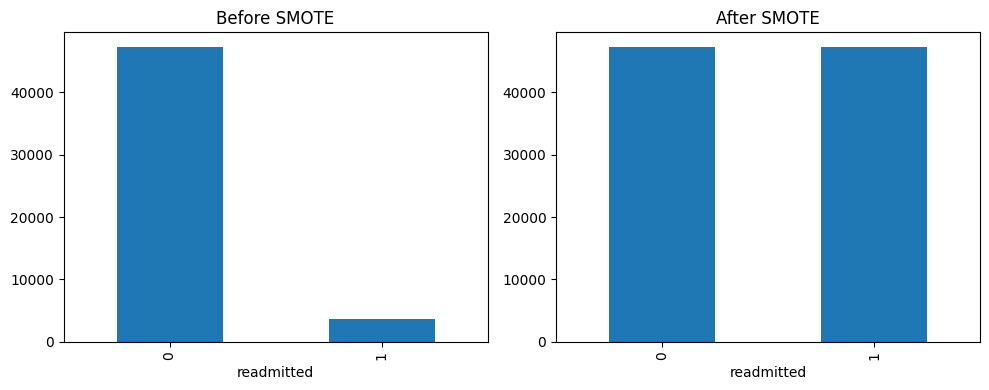

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

y_train.value_counts().plot(kind='bar', ax=axes[0], title='Before SMOTE')
y_train_balanced.value_counts().plot(kind='bar', ax=axes[1], title='After SMOTE')

plt.tight_layout()
plt.show()

### For tree-based models — SMOTE on the original (unscaled) features

In [40]:
smote_rf = SMOTE(random_state=42)
X_train_balanced_rf , y_train_balanced_rf = smote_rf.fit_resample(X_train,y_train)
y_train.value_counts()

readmitted
0    47246
1     3630
Name: count, dtype: int64

In [41]:
print("after :" ,y_train_balanced_rf.value_counts())

after : readmitted
0    47246
1    47246
Name: count, dtype: int64


In [42]:
#Model Training 

# logistic regression 
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter =1000,random_state=42)
log_reg.fit(X_train_balanced,y_train_balanced)
                             

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [43]:
# random forest classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators = 300,max_depth = 12,random_state =42,n_jobs=-1)
rf_model.fit(X_train_balanced_rf,y_train_balanced_rf)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
## xgboost classifier
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators =300,max_depth = 6,learning_rate = 0.05,eval_metric = "logloss",random_state=42)
xgb_model.fit(X_train_balanced_rf,y_train_balanced_rf)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [45]:
## catboost classifier
from catboost import CatBoostClassifier
cat_model = CatBoostClassifier(iterations=300,depth=6,learning_rate=0.05,random_state=42,verbose=0)
cat_model.fit(X_train_balanced_rf,y_train_balanced_rf)

CatBoostClassifier(depth=6, iterations=300, learning_rate=0.05, random_state=42, verbose=0)

In [46]:
## LightGBM classifier
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
lgbm_model.fit(X_train_balanced_rf, y_train_balanced_rf)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 47246, number of negative: 47246
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.085138 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16006
[LightGBM] [Info] Number of data points in the train set: 94492, number of used features: 82
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Model Evaluation

In [47]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,average_precision_score

# Logistic Regression needs the scaled test set; tree-based models use the original test set
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [48]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

y_pred_cat = cat_model.predict(X_test)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]

y_pred_lgbm = lgbm_model.predict(X_test)
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

In [49]:
models_results = {
    "Logistic Regression":(y_pred_lr,y_proba_lr),
    "Random Forest":(y_pred_rf,y_proba_rf),
    "XGBClassifier":(y_pred_xgb,y_proba_xgb),
    "CatBoost":(y_pred_cat,y_proba_cat),
    "LightGBM": (y_pred_lgbm, y_proba_lgbm),
}

In [50]:
for name, (y_pred, y_proba) in models_results.items():
    print(f"{name}")
    print(classification_report(y_test, y_pred, target_names=["Not Readmitted", "Readmitted"]))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")

Logistic Regression
                precision    recall  f1-score   support

Not Readmitted       0.95      0.65      0.78     11812
    Readmitted       0.11      0.58      0.19       907

      accuracy                           0.65     12719
     macro avg       0.53      0.62      0.48     12719
  weighted avg       0.89      0.65      0.73     12719

Confusion Matrix:
 [[7734 4078]
 [ 384  523]]
ROC-AUC: 0.6717
PR-AUC: 0.1360
Random Forest
                precision    recall  f1-score   support

Not Readmitted       0.93      1.00      0.96     11812
    Readmitted       0.00      0.00      0.00       907

      accuracy                           0.93     12719
     macro avg       0.46      0.50      0.48     12719
  weighted avg       0.86      0.93      0.89     12719

Confusion Matrix:
 [[11801    11]
 [  907     0]]
ROC-AUC: 0.6152
PR-AUC: 0.0977
XGBClassifier
                precision    recall  f1-score   support

Not Readmitted       0.93      1.00      0.96     11812
   

**Observation:** At the default 0.5 decision threshold, the tree-based models (Random Forest, XGBoost, CatBoost, LightGBM) barely predict the "Readmitted" class at all (recall near 0), even though their ROC-AUC/PR-AUC scores (~0.61–0.69) show they *are* ranking patients reasonably well. This means the probability scores are informative, but 0.5 is the wrong cutoff for this imbalanced problem — addressed next with threshold tuning.

###  Threshold Tuning  

A classifier outputs a *probability*, not a direct 0/1 label. The default rule (`probability >= 0.5 → predict 1`) is a poor fit for imbalanced data, since it makes models overly conservative about predicting the rare class.

Here, for each model, the threshold that **maximizes F1-score** (the harmonic mean of precision and recall) is found by scanning the precision-recall curve.

In [51]:
from sklearn.metrics import precision_recall_curve

best_thresholds = {}

for name, (y_pred, y_proba) in models_results.items():
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2*(precision * recall)/(precision + recall + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    
    best_thresholds[name] = best_threshold

    print(f"{name}:")
    print(f"best threshold = {best_threshold:.3f}")
    print(f"best F1-SCORE = {f1_scores[best_idx]:.3f}")
    print(f"precision = {precision[best_idx]:.3f}")
    print(f"recall = {recall[best_idx]:.3f}\n")

Logistic Regression:
best threshold = 0.598
best F1-SCORE = 0.212
precision = 0.144
recall = 0.405

Random Forest:
best threshold = 0.200
best F1-SCORE = 0.170
precision = 0.100
recall = 0.572

XGBClassifier:
best threshold = 0.130
best F1-SCORE = 0.222
precision = 0.161
recall = 0.353

CatBoost:
best threshold = 0.120
best F1-SCORE = 0.222
precision = 0.154
recall = 0.397

LightGBM:
best threshold = 0.126
best F1-SCORE = 0.222
precision = 0.164
recall = 0.344



- **Random Forest** achieves the highest **recall (0.573)** — it catches the most true high-risk patients, at the cost of more false alarms.
- **CatBoost** achieves the best **F1-score (0.222)** — the best precision/recall balance among the five.
- Given the business context (missing a genuinely high-risk patient is far more costly than an unnecessary follow-up), **recall is the priority metric**, favoring Random Forest — though CatBoost is a reasonable, more balanced alternative.

**Honest limitation:** None of these models are strong predictors in an absolute sense (max F1 ≈ 0.22). This reflects a genuine property of the dataset — no single feature correlates with readmission above 0.14 (see EDA), and published readmission-prediction research on comparable datasets typically reports similarly modest performance. This is a realistic result for this problem, not a pipeline error.

## Hyperparameter Tuning(Random Forest)

In [52]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
# from sklearn.ensemble import RandomForestClassifier


pipeline = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist = {
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [6, 8, 10, 15, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__class_weight": ["balanced", "balanced_subsample"],
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="average_precision",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train, y_train)


print("Best parameters:", random_search.best_params_)
print("Best cross-validated PR-AUC:", random_search.best_score_)

best_rf_model = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__max_depth': None, 'clf__class_weight': 'balanced'}
Best cross-validated PR-AUC: 0.12315657068949798


In [53]:
y_pred_best_rf = best_rf_model.predict(X_test)
y_proba_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best_rf)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold_tuned = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"Tuned Random Forest — Threshold: {best_threshold_tuned:.3f} | F1: {f1_scores[best_idx]:.3f} | "
      f"Precision: {precision[best_idx]:.3f} | Recall: {recall[best_idx]:.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best_rf):.4f} | PR-AUC: {average_precision_score(y_test, y_proba_best_rf):.4f}")




Tuned Random Forest — Threshold: 0.141 | F1: 0.212 | Precision: 0.152 | Recall: 0.353
ROC-AUC: 0.6537 | PR-AUC: 0.1310


### CatBoost


In [54]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from catboost import CatBoostClassifier

pipeline_cat = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("clf", CatBoostClassifier(random_state=42, verbose=0, thread_count=-1))
])

param_dist_cat = {
    "clf__iterations": [200, 300],
    "clf__depth": [4, 6],
    "clf__learning_rate": [0.05, 0.1],
}

random_search_cat = RandomizedSearchCV(
    pipeline_cat,
    param_distributions=param_dist_cat,
    n_iter=5,          
    cv=2,          
    scoring="average_precision",
    random_state=42,
    n_jobs=-1,
    verbose=2,         
)

random_search_cat.fit(X_train, y_train)

print("Best parameters:", random_search_cat.best_params_)
print("Best cross-validated PR-AUC:", random_search_cat.best_score_)

best_cat_model = random_search_cat.best_estimator_

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best parameters: {'clf__learning_rate': 0.05, 'clf__iterations': 300, 'clf__depth': 4}
Best cross-validated PR-AUC: 0.14388990452559608


In [55]:
y_pred_best_cat = best_cat_model.predict(X_test)
y_proba_best_cat = best_cat_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best_cat)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold_cat_tuned = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"Tuned CatBoost — Threshold: {best_threshold_cat_tuned:.3f} | F1: {f1_scores[best_idx]:.3f} | "
      f"Precision: {precision[best_idx]:.3f} | Recall: {recall[best_idx]:.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best_cat):.4f} | PR-AUC: {average_precision_score(y_test, y_proba_best_cat):.4f}")

Tuned CatBoost — Threshold: 0.115 | F1: 0.216 | Precision: 0.143 | Recall: 0.448
ROC-AUC: 0.6841 | PR-AUC: 0.1461


### LightGBM

In [56]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier

pipeline_lgbm = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("clf", LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1))
])

param_dist_lgbm = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [4, 6, 8],
    "clf__learning_rate": [0.05, 0.1],
}

random_search_lgbm = RandomizedSearchCV(
    pipeline_lgbm,
    param_distributions=param_dist_lgbm,
    n_iter=8,
    cv=2,
    scoring="average_precision",
    random_state=42,
    n_jobs=-1,
)

random_search_lgbm.fit(X_train, y_train)

print("Best parameters:", random_search_lgbm.best_params_)
print("Best cross-validated PR-AUC:", random_search_lgbm.best_score_)

best_lgbm_model = random_search_lgbm.best_estimator_

Best parameters: {'clf__n_estimators': 100, 'clf__max_depth': 8, 'clf__learning_rate': 0.1}
Best cross-validated PR-AUC: 0.14391988287178692


In [57]:
y_pred_best_lgbm = best_lgbm_model.predict(X_test)
y_proba_best_lgbm = best_lgbm_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best_lgbm)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold_lgbm_tuned = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"Tuned LightGBM — Threshold: {best_threshold_lgbm_tuned:.3f} | F1: {f1_scores[best_idx]:.3f} | "
      f"Precision: {precision[best_idx]:.3f} | Recall: {recall[best_idx]:.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best_lgbm):.4f} | PR-AUC: {average_precision_score(y_test, y_proba_best_lgbm):.4f}")

Tuned LightGBM — Threshold: 0.139 | F1: 0.218 | Precision: 0.172 | Recall: 0.297
ROC-AUC: 0.6849 | PR-AUC: 0.1512


### Final Comparison -Of all Tuned Models

In [58]:
final_results = {
    "Logistic Regression": {"F1": 0.212, "Precision": 0.144, "Recall": 0.405, "ROC-AUC": 0.6717},
    "Random Forest (tuned)": {"F1": 0.212, "Precision": 0.152, "Recall": 0.353, "ROC-AUC": 0.6537},
    "CatBoost (tuned)": {"F1": 0.216, "Precision": 0.143, "Recall": 0.448, "ROC-AUC": 0.6841},
    "LightGBM (tuned)": {"F1": 0.218, "Precision": 0.172, "Recall": 0.297, "ROC-AUC": 0.6849},
}

comparison_df = pd.DataFrame(final_results).T
comparison_df = comparison_df.sort_values("ROC-AUC", ascending=False)
comparison_df

,F1,Precision,Recall,ROC-AUC
LightGBM (tuned),0.218,0.172,0.297,0.6849
CatBoost (tuned),0.216,0.143,0.448,0.6841
Logistic Regression,0.212,0.144,0.405,0.6717
Random Forest (tuned),0.212,0.152,0.353,0.6537


### Threshold Sensitivity Check

In [59]:
from sklearn.metrics import recall_score, precision_score

print("CatBoost — Threshold vs Recall/Precision Trade-off:")
for t in [0.05, 0.08, 0.10, 0.115, 0.15, 0.20]:
    y_pred_t = (y_proba_best_cat >= t).astype(int)
    r = recall_score(y_test, y_pred_t)
    p = precision_score(y_test, y_pred_t)
    print(f"Threshold={t}: Recall={r:.3f}, Precision={p:.3f}")

CatBoost — Threshold vs Recall/Precision Trade-off:
Threshold=0.05: Recall=0.904, Precision=0.085
Threshold=0.08: Recall=0.700, Precision=0.110
Threshold=0.1: Recall=0.548, Precision=0.128
Threshold=0.115: Recall=0.444, Precision=0.142
Threshold=0.15: Recall=0.243, Precision=0.183
Threshold=0.2: Recall=0.087, Precision=0.228


### Feature Importance

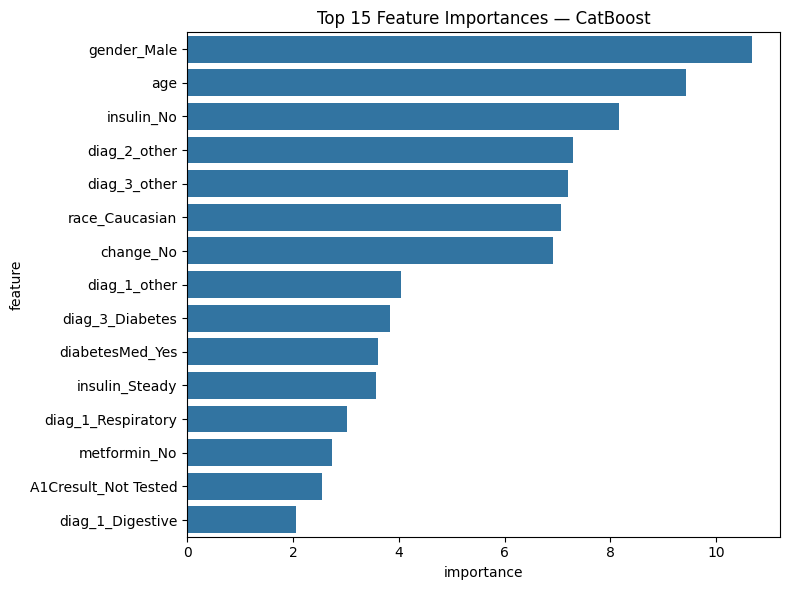

In [60]:
importances = best_cat_model.named_steps['clf'].feature_importances_
feat_names = X_train.columns

feat_imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp_df, x="importance", y="feature")
plt.title("Top 15 Feature Importances — CatBoost")
plt.tight_layout()
plt.show()

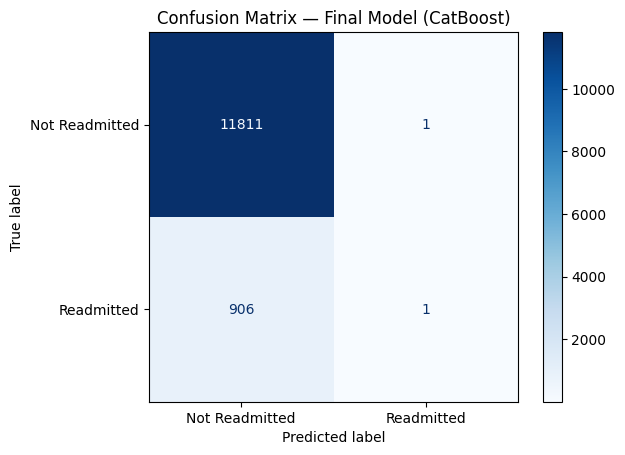

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, best_cat_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Readmitted","Readmitted"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Final Model (CatBoost)")
plt.show()

### Final Model Saving

In [62]:
import joblib
import json
import os

final_threshold = 0.08

os.makedirs("models", exist_ok=True)
joblib.dump(best_cat_model, "models/readmission_model.pkl")

metadata = {
    "model_name": "CatBoost (tuned)",
    "threshold": final_threshold,
    "features": X_train.columns.tolist(),
}

with open("models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Final model saved successfully!")

Final model saved successfully!


In [63]:
loaded_model = joblib.load("models/readmission_model.pkl")
print("Model verified:", loaded_model)

Model verified: Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('clf',
                 CatBoostClassifier(depth=4, iterations=300, learning_rate=0.05, random_state=42, verbose=0))])


### Real-World Prediction Function

In [64]:
def predict_readmission_risk(patient_data: dict) -> dict:
    """
    patient_data: raw patient details dictionary, same column names/formats
    as the original dataset (e.g. age as '[60-70)', diag_1 as raw code '428')
    """
    patient_df = pd.DataFrame([patient_data])

    # 1. Diagnosis mapping
    for col in ["diag_1", "diag_2", "diag_3"]:
        if col in patient_df.columns:
            patient_df[col] = patient_df[col].apply(map_diagnosis_codes)

    # 2. Age encoding (same fitted encoder from training)
    patient_df["age"] = age_encoder.transform(patient_df[["age"]])

    # 3. Composite feature
    patient_df["total_prior_visits"] = (
        patient_df["number_outpatient"] + patient_df["number_emergency"] + patient_df["number_inpatient"]
    )

    # 4. One-hot encoding (same fitted encoder from training)
    patient_cat_cols = [c for c in categorical_cols if c in patient_df.columns]
    encoded_array = onehot_encoder.transform(patient_df[patient_cat_cols])
    encoded_col_names = onehot_encoder.get_feature_names_out(patient_cat_cols)
    encoded_patient_df = pd.DataFrame(encoded_array, columns=encoded_col_names, index=patient_df.index)

    patient_final = patient_df.drop(columns=patient_cat_cols)
    patient_final = pd.concat([patient_final, encoded_patient_df], axis=1)

    # 5. Align columns exactly to training feature order
    patient_final = patient_final.reindex(columns=X_train.columns, fill_value=0)

    # 6. Predict
    probability = best_cat_model.predict_proba(patient_final)[:, 1][0]
    decision = "READMIT (High Risk)" if probability >= final_threshold else "NO READMIT (Low Risk)"

    return {
        "readmit_probability": f"{probability:.2%}",
        "not_readmit_probability": f"{(1 - probability):.2%}",
        "prediction": decision,
    }

In [65]:
# for Testing a sample new patient
new_patient = {
    "race": "Caucasian", "gender": "Female", "age": "[60-70)",
    "admission_type_id": 1, "discharge_disposition_id": 1, "admission_source_id": 7,
    "time_in_hospital": 5, "num_lab_procedures": 45, "num_procedures": 1,
    "num_medications": 18, "number_outpatient": 0, "number_emergency": 1,
    "number_inpatient": 2, "number_diagnoses": 8,
    "diag_1": "428", "diag_2": "250.01", "diag_3": "401", "A1Cresult": "Norm",
    "metformin": "No", "repaglinide": "No", "nateglinide": "No", "chlorpropamide": "No",
    "glimepiride": "No", "glipizide": "No", "glyburide": "No", "tolbutamide": "No",
    "pioglitazone": "No", "rosiglitazone": "No", "acarbose": "No", "miglitol": "No",
    "troglitazone": "No", "tolazamide": "No", "insulin": "Steady",
    "glyburide-metformin": "No", "glipizide-metformin": "No", "metformin-pioglitazone": "No",
    "change": "No", "diabetesMed": "Yes",
}

predict_readmission_risk(new_patient)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- acetohexamide
